# Games Dataset — Exploratory Data Analysis
Unified dataset from Steam, PlayStation and Nintendo (~38 800 games)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/games_unified.csv')

# parse list-like columns stored as strings
for col in ('genre', 'features'):
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(3)

Rows: 38,801  |  Columns: 17


,source_platform,source_id,title,publisher,developer,release_date,release_year,genre,price,critic_score,user_score,positive_ratings,negative_ratings,average_playtime,owners,features,raw_source
0,steam,10,Counter-Strike,Valve,Valve,2000-11-01,2000.0,[Action],7.19,NaN,NaN,124534.0,3339.0,17612.0,10000000-20000000,"[Multi-player, Online Multi-Player, Local Mult...","{'platforms': 'windows;mac;linux', 'steamspy_t..."
1,steam,20,Team Fortress Classic,Valve,Valve,1999-04-01,1999.0,[Action],3.99,NaN,NaN,3318.0,633.0,277.0,5000000-10000000,"[Multi-player, Online Multi-Player, Local Mult...","{'platforms': 'windows;mac;linux', 'steamspy_t..."
2,steam,30,Day of Defeat,Valve,Valve,2003-05-01,2003.0,[Action],3.99,NaN,NaN,3416.0,398.0,187.0,5000000-10000000,"[Multi-player, Valve Anti-Cheat enabled]","{'platforms': 'windows;mac;linux', 'steamspy_t..."


## 1. Dataset Overview

In [2]:
print('=== dtypes ===')
print(df.dtypes)
print()
print('=== Basic numeric stats ===')
df[['release_year','price','critic_score','user_score',
    'positive_ratings','negative_ratings','average_playtime']].describe()

=== dtypes ===
source_platform         str
source_id             int64
title                   str
publisher               str
developer               str
release_date            str
release_year        float64
genre                object
price               float64
critic_score        float64
user_score          float64
positive_ratings    float64
negative_ratings    float64
average_playtime    float64
owners                  str
features             object
raw_source              str
dtype: object

=== Basic numeric stats ===


,release_year,price,critic_score,user_score,positive_ratings,negative_ratings,average_playtime
count,37621.000000,27075.000000,131.000000,83.000000,2.707500e+04,27075.000000,27075.000000
mean,2017.064379,6.078193,7.671756,8.003614,1.000559e+03,211.027147,149.804949
std,2.279815,7.874922,1.315194,1.737214,1.898872e+04,4284.938531,1827.038141
min,1997.000000,0.000000,2.000000,1.000000,0.000000e+00,0.000000,0.000000
25%,2016.000000,1.690000,7.000000,7.000000,6.000000e+00,2.000000,0.000000
50%,2017.000000,3.990000,8.000000,8.400000,2.400000e+01,9.000000,0.000000
75%,2018.000000,7.190000,8.500000,9.100000,1.260000e+02,42.000000,0.000000
max,2022.000000,421.990000,9.900000,10.000000,2.644404e+06,487076.000000,190625.000000


## 2. Missing Values

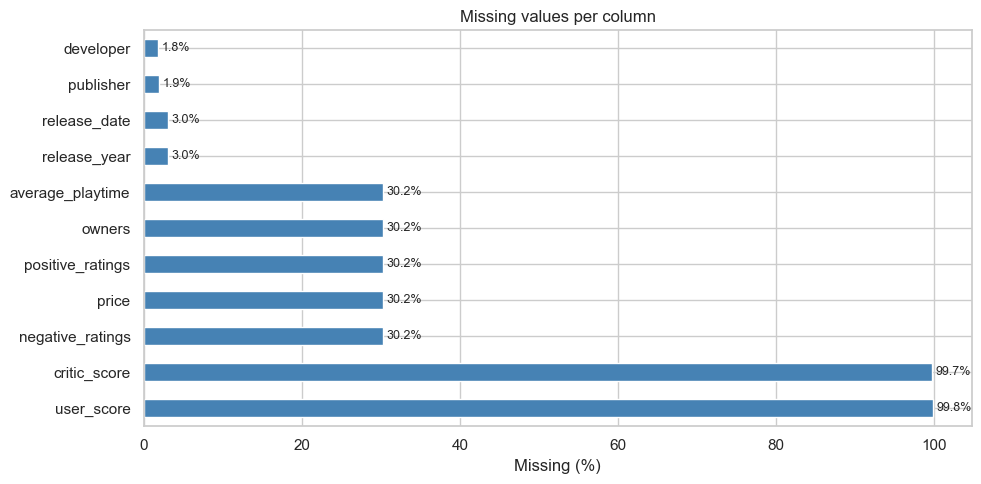


Missing count per column:
publisher             745
developer             701
release_date         1180
release_year         1180
price               11726
critic_score        38670
user_score          38718
positive_ratings    11726
negative_ratings    11726
average_playtime    11726
owners              11726
dtype: int64


In [3]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
null_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values per column')
for bar, val in zip(ax.patches, null_pct):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nMissing count per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

## 3. Platform Distribution

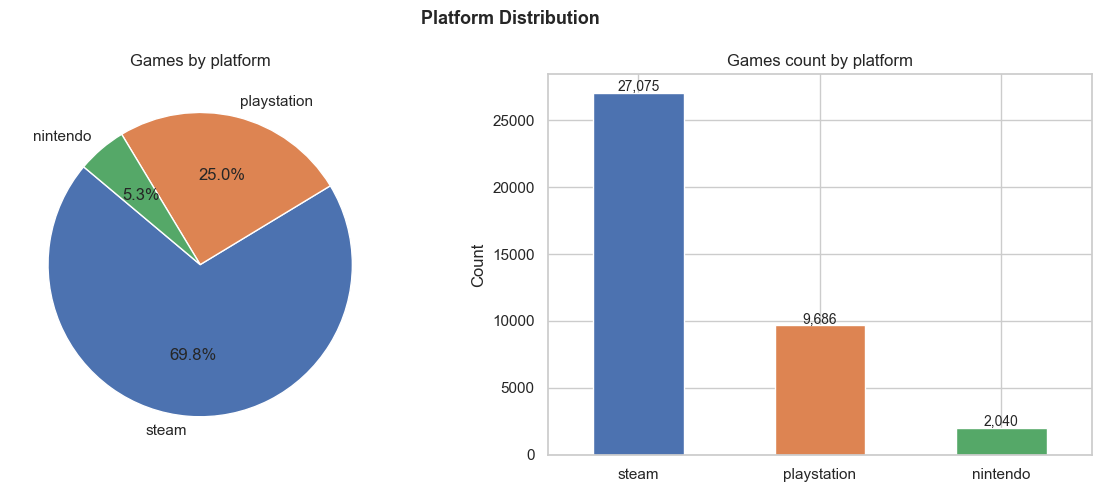

source_platform
steam          27075
playstation     9686
nintendo        2040


In [4]:
plat_counts = df['source_platform'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# pie
ax1.pie(plat_counts, labels=plat_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0','#DD8452','#55A868'], startangle=140)
ax1.set_title('Games by platform')

# bar
plat_counts.plot(kind='bar', ax=ax2, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
ax2.set_title('Games count by platform')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)
for bar in ax2.patches:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.suptitle('Platform Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(plat_counts.to_string())

## 4. Release Year Distribution

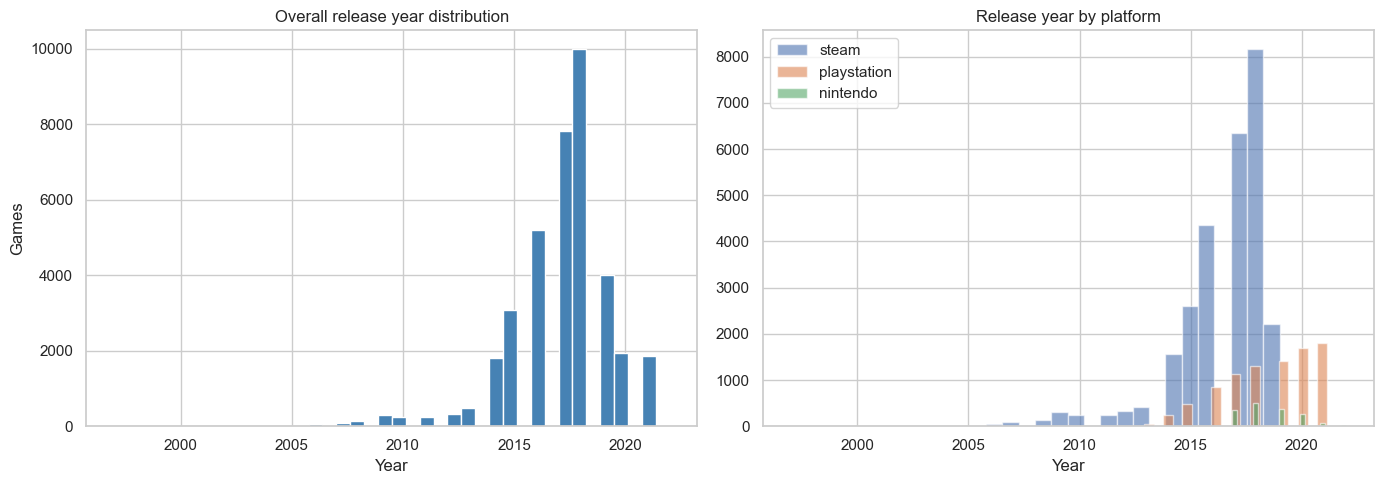


Top 5 years by game count:
release_year
2018.0    9987
2017.0    7832
2016.0    5203
2019.0    3999
2015.0    3075
Name: count, dtype: int64


In [5]:
years = df[df['release_year'].between(1980, 2024)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall histogram
axes[0].hist(years['release_year'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Overall release year distribution')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Games')

# per platform
for plat, color in zip(['steam','playstation','nintendo'], ['#4C72B0','#DD8452','#55A868']):
    subset = years[years['source_platform'] == plat]['release_year'].dropna()
    axes[1].hist(subset, bins=30, alpha=0.6, label=plat, color=color, edgecolor='white')
axes[1].set_title('Release year by platform')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nTop 5 years by game count:')
print(years['release_year'].value_counts().head())

## 5. Genre Analysis

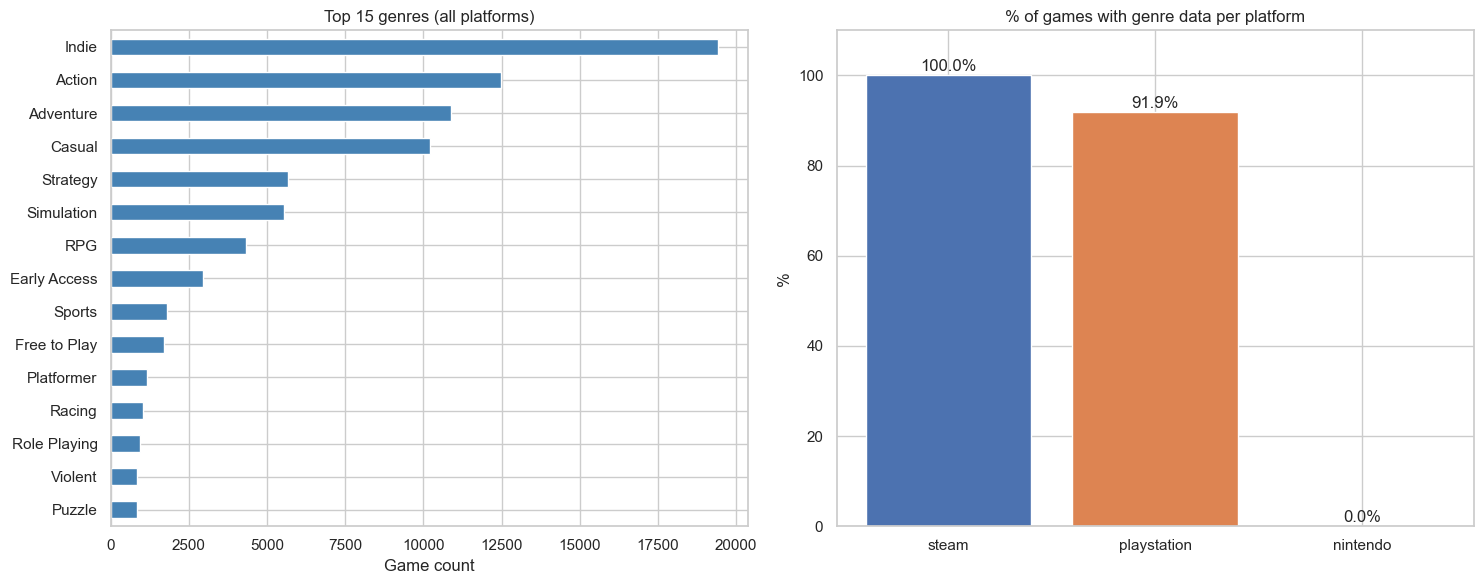


Total unique genres: 109
Top 10: ['Indie', 'Action', 'Adventure', 'Casual', 'Strategy', 'Simulation', 'RPG', 'Early Access', 'Sports', 'Free to Play']


In [6]:
from collections import Counter

all_genres = Counter(g for genres in df['genre'] for g in genres)
top_genres = pd.Series(dict(all_genres.most_common(15)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_genres.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 genres (all platforms)')
axes[0].set_xlabel('Game count')
axes[0].invert_yaxis()

# genre availability per platform
genre_data = {'Platform': [], 'Has genre': []}
for plat in ['steam', 'playstation', 'nintendo']:
    sub = df[df['source_platform'] == plat]
    has_genre = sub['genre'].apply(lambda x: len(x) > 0).sum()
    genre_data['Platform'].append(plat)
    genre_data['Has genre'].append(has_genre / len(sub) * 100)

colors = ['#4C72B0','#DD8452','#55A868']
bars = axes[1].bar(genre_data['Platform'], genre_data['Has genre'], color=colors, edgecolor='white')
axes[1].set_title('% of games with genre data per platform')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, genre_data['Has genre']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print(f'\nTotal unique genres: {len(all_genres)}')
print('Top 10:', list(top_genres.index[:10]))

## 6. Price Analysis (Steam)

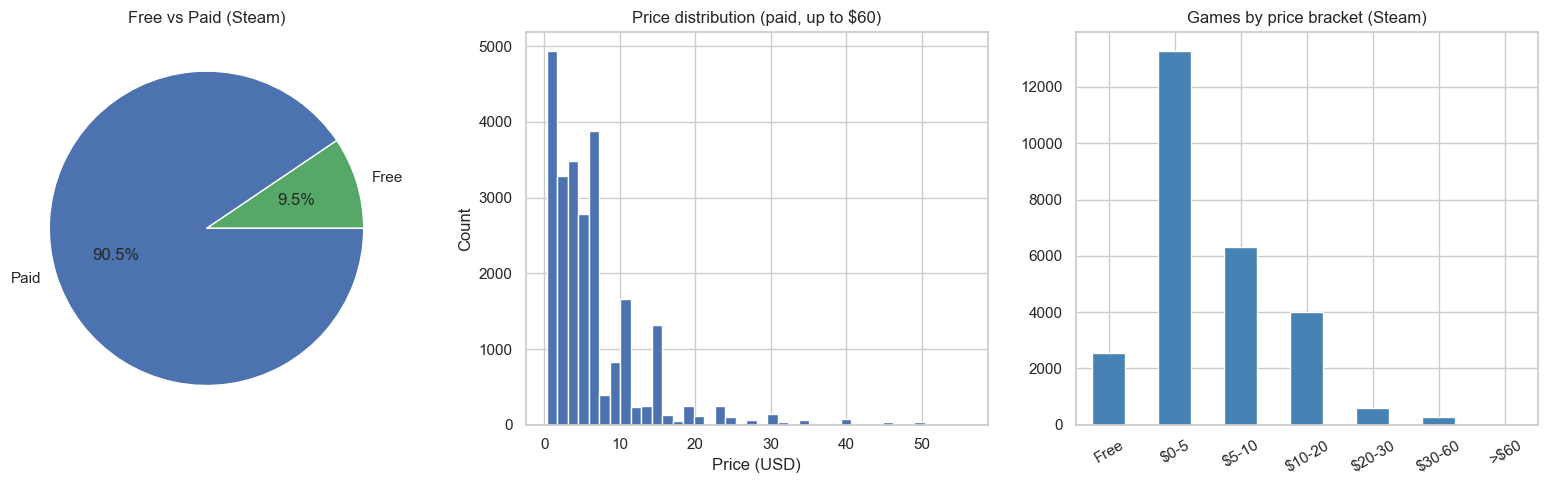

Paid games: 24,515 | Median: $4.79 | Mean: $6.71 | Max: $421.99


In [7]:
steam = df[df['source_platform'] == 'steam'].copy()
steam_priced = steam[steam['price'].notna() & (steam['price'] >= 0)]

free = (steam_priced['price'] == 0).sum()
paid = (steam_priced['price'] > 0).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# free vs paid
axes[0].pie([free, paid], labels=['Free', 'Paid'],
            autopct='%1.1f%%', colors=['#55A868','#4C72B0'])
axes[0].set_title('Free vs Paid (Steam)')

# price distribution (paid, < $60)
paid_games = steam_priced[steam_priced['price'].between(0.01, 60)]
axes[1].hist(paid_games['price'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('Price distribution (paid, up to $60)')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Count')

# price brackets
brackets = pd.cut(steam_priced['price'],
                  bins=[-0.01, 0, 5, 10, 20, 30, 60, 1000],
                  labels=['Free','$0-5','$5-10','$10-20','$20-30','$30-60','>$60'])
brackets.value_counts().sort_index().plot(kind='bar', ax=axes[2],
                                           color='steelblue', edgecolor='white')
axes[2].set_title('Games by price bracket (Steam)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

paid_only = steam_priced[steam_priced['price'] > 0]['price']
print(f'Paid games: {paid:,} | Median: ${paid_only.median():.2f} | Mean: ${paid_only.mean():.2f} | Max: ${paid_only.max():.2f}')

## 7. Steam Ratings Analysis

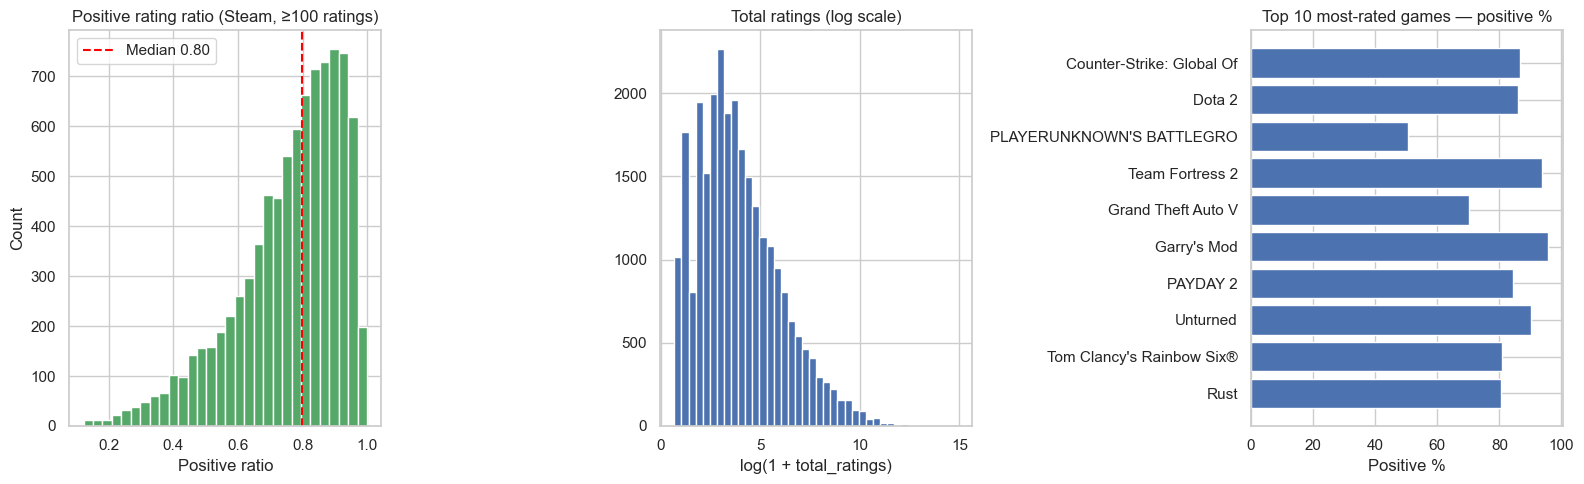

Games with ratings: 27,075
Median positive ratio: 0.797


In [8]:
rated = steam[steam['positive_ratings'].notna() & steam['negative_ratings'].notna()].copy()
rated['total_ratings'] = rated['positive_ratings'] + rated['negative_ratings']
rated['positive_ratio'] = rated['positive_ratings'] / rated['total_ratings'].replace(0, np.nan)

popular = rated[rated['total_ratings'] >= 100]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# positive ratio distribution
axes[0].hist(popular['positive_ratio'].dropna(), bins=30,
             color='#55A868', edgecolor='white')
axes[0].set_title('Positive rating ratio (Steam, ≥100 ratings)')
axes[0].set_xlabel('Positive ratio')
axes[0].set_ylabel('Count')
axes[0].axvline(popular['positive_ratio'].median(), color='red',
                linestyle='--', label=f'Median {popular["positive_ratio"].median():.2f}')
axes[0].legend()

# log scale total ratings
axes[1].hist(np.log1p(rated['total_ratings']), bins=40,
             color='#4C72B0', edgecolor='white')
axes[1].set_title('Total ratings (log scale)')
axes[1].set_xlabel('log(1 + total_ratings)')

# top 10 most rated
top10 = rated.nlargest(10, 'total_ratings')[['title','total_ratings','positive_ratio']]
axes[2].barh(top10['title'].str[:25], top10['positive_ratio'] * 100, color='#4C72B0')
axes[2].set_title('Top 10 most-rated games — positive %')
axes[2].set_xlabel('Positive %')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Games with ratings: {len(rated):,}')
print(f'Median positive ratio: {popular["positive_ratio"].median():.3f}')

## 8. Critic & User Scores (Nintendo)

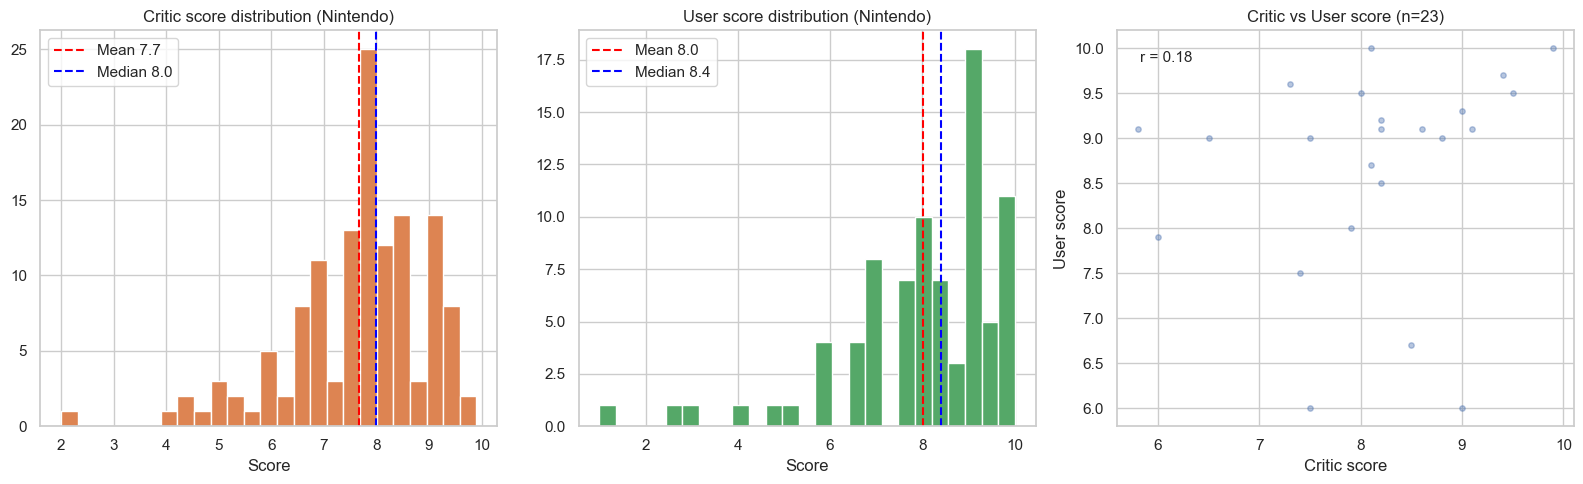

Critic score — mean: 7.67, std: 1.32, min: 2.0, max: 9.9
User score  — mean: 8.00, std: 1.74, min: 1.0, max: 10.0


In [9]:
nintendo = df[df['source_platform'] == 'nintendo'].copy()
scored = nintendo[nintendo['critic_score'].notna() | nintendo['user_score'].notna()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# critic score distribution
cs = nintendo['critic_score'].dropna()
axes[0].hist(cs, bins=25, color='#DD8452', edgecolor='white')
axes[0].axvline(cs.mean(), color='red', linestyle='--', label=f'Mean {cs.mean():.1f}')
axes[0].axvline(cs.median(), color='blue', linestyle='--', label=f'Median {cs.median():.1f}')
axes[0].set_title('Critic score distribution (Nintendo)')
axes[0].set_xlabel('Score')
axes[0].legend()

# user score distribution
us = nintendo['user_score'].dropna()
axes[1].hist(us, bins=25, color='#55A868', edgecolor='white')
axes[1].axvline(us.mean(), color='red', linestyle='--', label=f'Mean {us.mean():.1f}')
axes[1].axvline(us.median(), color='blue', linestyle='--', label=f'Median {us.median():.1f}')
axes[1].set_title('User score distribution (Nintendo)')
axes[1].set_xlabel('Score')
axes[1].legend()

# critic vs user scatter
both = nintendo[nintendo['critic_score'].notna() & nintendo['user_score'].notna()]
axes[2].scatter(both['critic_score'], both['user_score'],
                alpha=0.4, color='#4C72B0', s=15)
axes[2].set_title(f'Critic vs User score (n={len(both):,})')
axes[2].set_xlabel('Critic score')
axes[2].set_ylabel('User score')
corr = both['critic_score'].corr(both['user_score'])
axes[2].text(0.05, 0.92, f'r = {corr:.2f}', transform=axes[2].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

print(f'Critic score — mean: {cs.mean():.2f}, std: {cs.std():.2f}, min: {cs.min()}, max: {cs.max()}')
print(f'User score  — mean: {us.mean():.2f}, std: {us.std():.2f}, min: {us.min()}, max: {us.max()}')

## 9. Playtime Analysis (Steam)

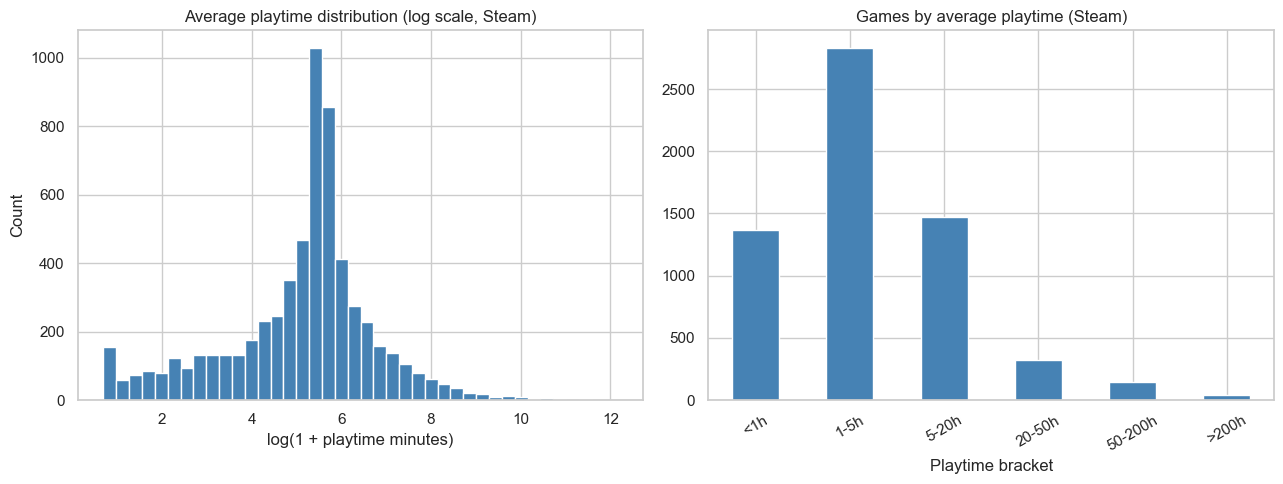

Playtime (hours) — median: 3.7 | mean: 11.0 | 90th pct: 15.8

Top 5 games by playtime:
                               title       hours
         The Abbey of Crime Extensum 3177.083333
           The Banner Saga: Factions 1587.416667
The Secret of Tremendous Corporation 1587.366667
                               PRICE 1058.016667
                           Boundless  920.066667


In [10]:
play = steam[steam['average_playtime'].notna() & (steam['average_playtime'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# log distribution
axes[0].hist(np.log1p(play['average_playtime']), bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('Average playtime distribution (log scale, Steam)')
axes[0].set_xlabel('log(1 + playtime minutes)')
axes[0].set_ylabel('Count')

# playtime brackets
h = play['average_playtime'] / 60
brackets = pd.cut(h, bins=[0, 1, 5, 20, 50, 200, 10000],
                  labels=['<1h','1-5h','5-20h','20-50h','50-200h','>200h'])
brackets.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Games by average playtime (Steam)')
axes[1].set_xlabel('Playtime bracket')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

h_arr = play['average_playtime'].values / 60
print(f'Playtime (hours) — median: {np.median(h_arr):.1f} | mean: {np.mean(h_arr):.1f} | 90th pct: {np.percentile(h_arr, 90):.1f}')

top5 = play.nlargest(5, 'average_playtime')[['title','average_playtime']]
top5['hours'] = top5['average_playtime'] / 60
print('\nTop 5 games by playtime:')
print(top5[['title','hours']].to_string(index=False))

## 10. Top Publishers

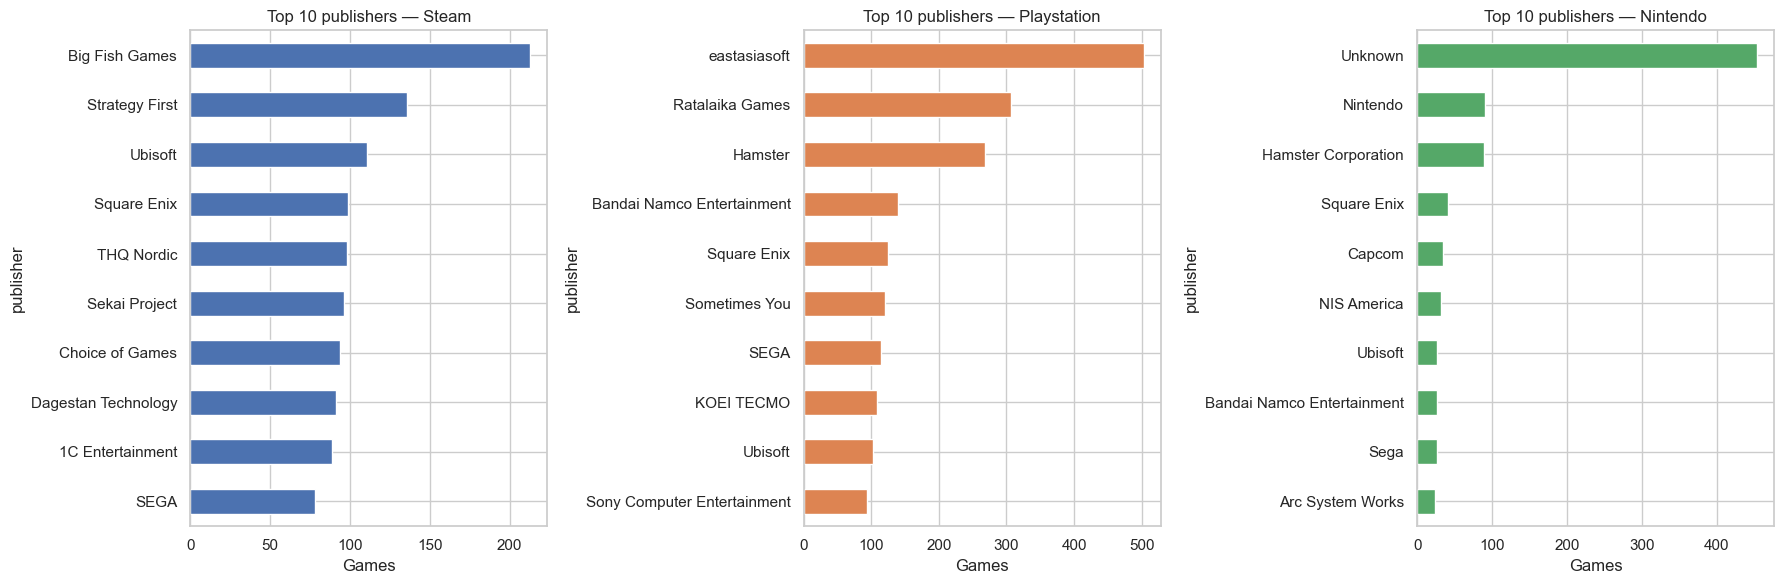

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, plat, color in zip(axes,
                            ['steam', 'playstation', 'nintendo'],
                            ['#4C72B0', '#DD8452', '#55A868']):
    sub = df[df['source_platform'] == plat]
    top = sub['publisher'].dropna().value_counts().head(10)
    top.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top 10 publishers — {plat.capitalize()}')
    ax.set_xlabel('Games')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Summary Statistics (NumPy)

In [12]:
print('=== Dataset Summary ===')
print(f'Total games:            {len(df):>8,}')
for plat in ['steam','playstation','nintendo']:
    n = (df['source_platform'] == plat).sum()
    print(f'  {plat:<15}         {n:>8,}')

print(f'\nRelease year range:     {int(df["release_year"].min())} – {int(df["release_year"].max())}')
print(f'Unique publishers:      {df["publisher"].nunique():>8,}')
print(f'Unique genres:          {len(all_genres):>8,}')

steam_p = df[(df['source_platform']=='steam') & df['price'].notna()]['price']
print(f'\nSteam price (paid):')
print(f'  mean   ${steam_p[steam_p>0].mean():.2f}')
print(f'  median ${steam_p[steam_p>0].median():.2f}')
print(f'  std    ${steam_p[steam_p>0].std():.2f}')

cs_arr = df['critic_score'].dropna().values
print(f'\nNintendo critic scores:')
print(f'  mean   {np.mean(cs_arr):.2f}')
print(f'  std    {np.std(cs_arr):.2f}')
print(f'  25/50/75 pct: {np.percentile(cs_arr,[25,50,75])}')

pos = df['positive_ratings'].dropna().values
neg = df['negative_ratings'].dropna().values
print(f'\nSteam ratings (games with data):')
print(f'  positive — median {np.median(pos):.0f}, max {np.max(pos):,}')
print(f'  negative — median {np.median(neg):.0f}, max {np.max(neg):,}')

=== Dataset Summary ===
Total games:              38,801
  steam                     27,075
  playstation                9,686
  nintendo                   2,040

Release year range:     1997 – 2022
Unique publishers:        15,528
Unique genres:               109

Steam price (paid):
  mean   $6.71
  median $4.79
  std    $8.01

Nintendo critic scores:
  mean   7.67
  std    1.31
  25/50/75 pct: [7.  8.  8.5]

Steam ratings (games with data):
  positive — median 24, max 2,644,404.0
  negative — median 9, max 487,076.0
